# Medidas de posição e dispersão #

### Entregável obrigatório ###

No mesmo dataset da semana 1, calcular **para pelo menos 3 variáveis numéricas**: média, mediana, min, maz, desvio padrão. Escrever um parágrafo interpretando cada uma (ex.: "clientes gastam em média X, mas há grande variação...").

In [143]:
#Importando a biblioteca

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Mostrando as primeiras linhas do data frame

df = pd.read_csv("economy.csv")
df

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"
...,...,...,...,...,...,...,...,...,...,...,...
206769,31-03-2022,Vistara,UK,832,07:05,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,"7,697"
206770,31-03-2022,Vistara,UK,832,07:05,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,"7,709"
206771,31-03-2022,Vistara,UK,826,12:30,Chennai,20h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,"8,640"
206772,31-03-2022,Vistara,UK,822,09:45,Chennai,23h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,"8,640"


In [32]:
df.dtypes

date          object
airline       object
ch_code       object
num_code       int64
dep_time      object
from          object
time_taken    object
stop          object
arr_time      object
to            object
price         object
dtype: object

In [33]:
# Converter a coluna 'price' de object para int 

df["price"] = df["price"].str.replace(",","") #remove vírgulas
df["price"] = pd.to_numeric(df["price"], errors="coerce") #converte para numérico

In [34]:
df.dtypes

date          object
airline       object
ch_code       object
num_code       int64
dep_time      object
from          object
time_taken    object
stop          object
arr_time      object
to            object
price          int64
dtype: object

In [95]:
# Converter a coluna 'dep_time' para date time

df["dep_time"] = pd.to_datetime(df["dep_time"], format="%H:%M")

In [96]:
# Criar a coluna com minutos desde meia-noite

df["dep_time_hour"] = (df["dep_time"].dt.hour * 60 + df["dep_time"].dt.minute)/60
df

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,time_taken_hour,dep_time_hour
0,11-02-2022,SpiceJet,SG,8709,1900-01-01 18:55:00,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,2.17,18.916667
1,11-02-2022,SpiceJet,SG,8157,1900-01-01 06:20:00,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,2.33,6.333333
2,11-02-2022,AirAsia,I5,764,1900-01-01 04:25:00,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,2.17,4.416667
3,11-02-2022,Vistara,UK,995,1900-01-01 10:20:00,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,2.25,10.333333
4,11-02-2022,Vistara,UK,963,1900-01-01 08:50:00,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,2.33,8.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
206769,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7697,13.83,7.083333
206770,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7709,13.83,7.083333
206771,31-03-2022,Vistara,UK,826,1900-01-01 12:30:00,Chennai,20h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,20.58,12.500000
206772,31-03-2022,Vistara,UK,822,1900-01-01 09:45:00,Chennai,23h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,23.33,9.750000


In [126]:
# Converter a coluna 'time_taken' para objeto datetime

df[["hours","minutes"]] = df["time_taken"].str.extract(r'(\d+)h\s*(\d+)m') #extrair horas e minutos em uma única linha
df[["hours","minutes"]] = df[["hours","minutes"]].fillna(0).astype(int) #prrenche os valores ausentes antes de converter

In [127]:
# Converter para inteiro e calcular total em minutos

df = df.astype({"hours": int,"minutes":int})
df["time_taken_hour"] = round((df["hours"] * 60 + df["minutes"])/60,2)
df = df.drop(columns = ["hours","minutes"])
df

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,time_taken_hour,dep_time_hour,time_taken_min
0,11-02-2022,SpiceJet,SG,8709,1900-01-01 18:55:00,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,2.17,18.916667,130
1,11-02-2022,SpiceJet,SG,8157,1900-01-01 06:20:00,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,2.33,6.333333,140
2,11-02-2022,AirAsia,I5,764,1900-01-01 04:25:00,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,2.17,4.416667,130
3,11-02-2022,Vistara,UK,995,1900-01-01 10:20:00,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,2.25,10.333333,135
4,11-02-2022,Vistara,UK,963,1900-01-01 08:50:00,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,2.33,8.833333,140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206769,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7697,13.83,7.083333,830
206770,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7709,13.83,7.083333,830
206771,31-03-2022,Vistara,UK,826,1900-01-01 12:30:00,Chennai,20h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,20.58,12.500000,1235
206772,31-03-2022,Vistara,UK,822,1900-01-01 09:45:00,Chennai,23h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,23.33,9.750000,1400


In [136]:
# Estatísticas básicas de preço

media = round(df["price"].mean(),2)
mediana = np.median(df["price"])
minimo = np.min(df["price"])
maximo = np.max(df["price"])
desvio_padrao = round(np.std(df["price"]),2)

print("Em média o preço de um voo é",media)
print("Metade dos preços do voo estão abaixo do valor de",mediana)
print("O valor mínimo do preço do voo é",minimo)
print("O valor máximo do preço do voo é:",maximo)
print("Com variação de:", desvio_padrao) #mostra o quanto os valores estão espalhados em relação a média

Em média o preço de um voo é 6571.19
Metade dos preços do voo estão abaixo do valor de 5772.0
O valor mínimo do preço do voo é 1105
O valor máximo do preço do voo é: 42349
Com variação de: 3743.43


In [137]:
# Estatísticas básicas do horário de partida do vôo

media = round(df["dep_time_hour"].mean(),2)
mediana = round(np.median(df["dep_time_hour"]),2)
minimo = round(np.min(df["dep_time_hour"]),2)
maximo = round(np.max(df["dep_time_hour"]),2)
desvio_padrao = round(np.std(df["dep_time_hour"]),2)

print("Em média o horário de partida de um voo é",media, "h")
print("Metade dos horários de partida dos voos estão abaixo abaixo do valor de ",mediana,"h")
print("O mínimo de horário de partida de um voo é ",minimo, "h")
print("O máximo de horário de partida de um voo é :",maximo,"h")
print("Com variação de:", desvio_padrao, "h") #mostra o quanto os valores estão espalhados em relação a média

Em média o horário de partida de um voo é 13.29 h
Metade dos horários de partida dos voos estão abaixo abaixo do valor de  12.83 h
O mínimo de horário de partida de um voo é  0.17 h
O máximo de horário de partida de um voo é : 23.92 h
Com variação de: 5.38 h


In [138]:
# Estatísticas básicas do tempo de voo

media = round(df["time_taken_hour"].mean(),2)
mediana = round(np.median(df["time_taken_hour"]),2)
minimo = round(np.min(df["time_taken_hour"]),2)
maximo = round(np.max(df["time_taken_hour"]),2)
desvio_padrao = round(np.std(df["time_taken_hour"]),2)

print("Em média um voo tem duração de ",media, "h")
print("Metade das durações dos voos estão abaixo do valor de",mediana, "h")
print("O mínimo de duração de um voo é de:",minimo, "h")
print("O máximo de duração de um voo é de:",maximo, "h")
print("Com variação de:", desvio_padrao, "h") #mostra o quanto os valores estão espalhados em relação a média

Em média um voo tem duração de  11.55 h
Metade das durações dos voos estão abaixo do valor de 10.17 h
O mínimo de duração de um voo é de: 0.0 h
O máximo de duração de um voo é de: 49.83 h
Com variação de: 7.24 h


### Entregável avançado ###

Em Python: criar um **dataframe de resumo estatístico** (describe + medidas que faltarem) e **gerar 1 gráfico** (histograma ou boxplot) por variável, salvando ou exibindo no notebook.

In [139]:
df.describe()

,num_code,price,time_taken_hour,dep_time_hour,time_taken_min
count,206774.000000,206774.000000,206774.000000,206774.000000,206774.000000
mean,1706.096714,6571.190701,11.545704,13.292137,692.740407
std,2320.463721,3743.442838,7.242261,5.383040,434.535568
min,101.000000,1105.000000,0.000000,0.166667,0.000000
25%,588.000000,4173.000000,6.250000,8.500000,375.000000
50%,818.000000,5772.000000,10.170000,12.833333,610.000000
75%,960.000000,7746.000000,15.250000,18.166667,915.000000
max,9991.000000,42349.000000,49.830000,23.916667,2990.000000


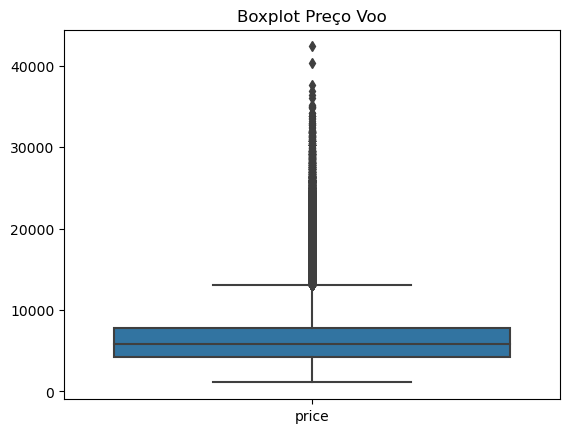

In [156]:
# Gráfico de boxplot da variável 'price'

sns.boxplot(data=df[["price"]])
plt.title("Boxplot Preço Voo")
plt.show()

- A linha dentro da caixa é a mediana, que está em torno de 6000.
- A linha inferior da caixa é o primeiro quartil, ou seja, onde estão 25% dos dados. Já na linha superior da caixa está o terceiro quartil, ou seja, 75% dos dados.
- Fora da caixa existem as linhas inferior e superior que determinam os outliers. É possível observar que em relação ao preço temos bastante dados outliers acima de ~15000.
- Caixa larga implica em dados espalhados, com grande variação.

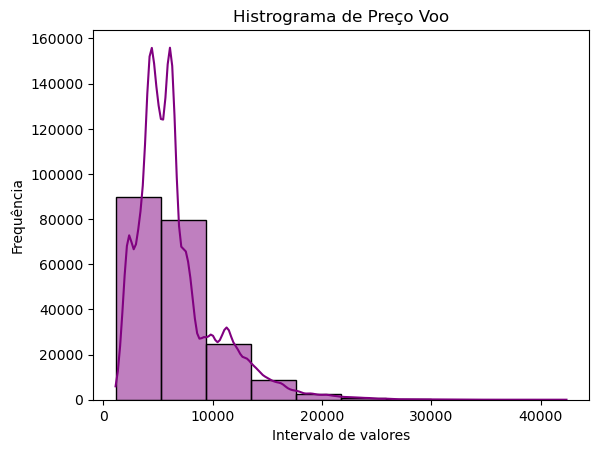

In [159]:
# Histograma da variável 'price'

sns.histplot(df["price"], bins=10, kde=True, color="purple")
plt.title("Histrograma de Preço Voo")
plt.xlabel("Intervalo de valores")
plt.ylabel("Frequência")
plt.show()

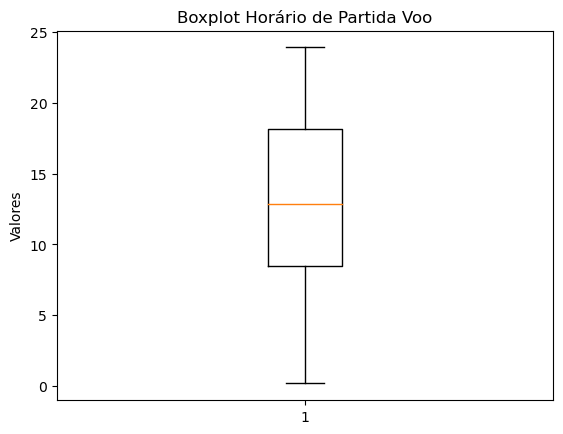

In [157]:
# Gráfico de boxplot da variável 'dep_time'

plt.boxplot(df["dep_time_hour"])
plt.title("Boxplot Horário de Partida Voo")
plt.ylabel("Valores")
plt.show()

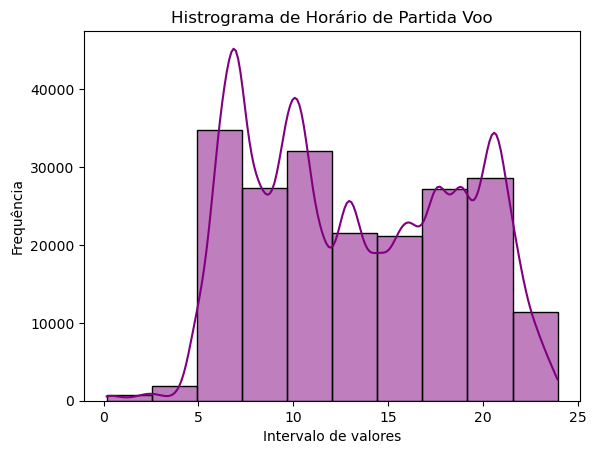

In [160]:
# Histograma da variável 'dep_time'

sns.histplot(df["dep_time_hour"], bins=10, kde=True, color="purple")
plt.title("Histrograma de Horário de Partida Voo")
plt.xlabel("Intervalo de valores")
plt.ylabel("Frequência")
plt.show()

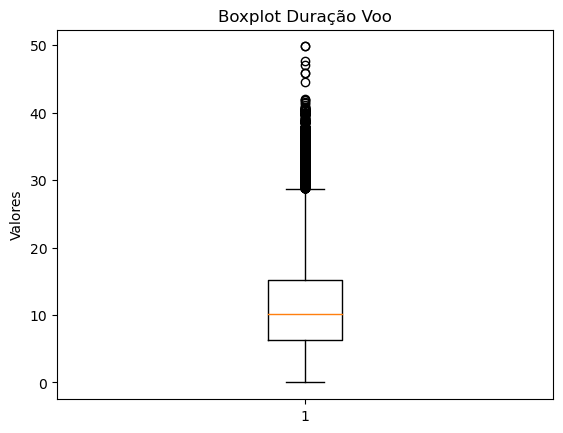

In [158]:
# Gráfico de boxplot da variável 'time_taken'

plt.boxplot(df["time_taken_hour"])
plt.title("Boxplot Duração Voo")
plt.ylabel("Valores")
plt.show()

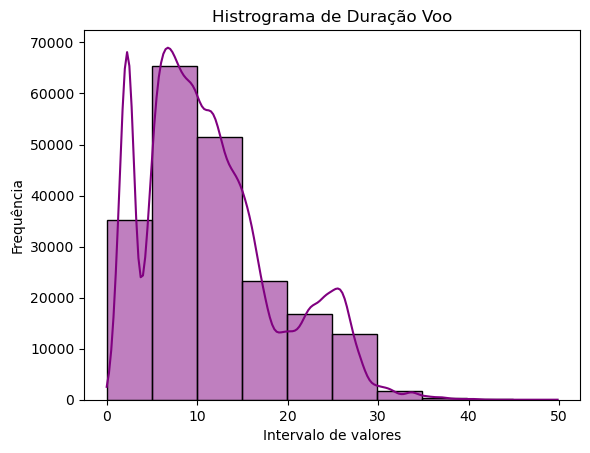

In [161]:
# Histograma da variável 'time_taken'

sns.histplot(df["time_taken_hour"], bins=10, kde=True, color="purple")
plt.title("Histrograma de Duração Voo")
plt.xlabel("Intervalo de valores")
plt.ylabel("Frequência")
plt.show()